In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv('tested.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [47]:
df.head()

df = df.fillna(df.mean())


In [48]:
y=df["Survived"].values
X=df.drop('Survived',axis=1)


X.head()

,Pclass,Age,SibSp,Parch,Fare
0,3,34.5,0,0,7.8292
1,3,47.0,1,0,7.0000
2,2,62.0,0,0,9.6875
3,3,27.0,0,0,8.6625
4,3,22.0,1,1,12.2875


In [49]:
X_train,X_test,y_train,y_test=train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape


(334, 5)

In [50]:
X_test.shape

X_train

,Pclass,Age,SibSp,Parch,Fare
336,2,32.00000,0,0,13.0000
31,2,24.00000,2,0,31.5000
84,2,30.27259,0,0,10.7083
287,1,24.00000,1,0,82.2667
317,2,19.00000,0,0,10.5000
...,...,...,...,...,...
71,3,21.00000,0,0,7.8958
106,3,21.00000,0,0,7.8208
270,1,46.00000,0,0,75.2417
348,2,24.00000,0,0,13.5000


In [51]:
from sklearn.preprocessing import StandardScaler

In [52]:
scaler=StandardScaler()
scaler.fit(X_train)
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)




In [53]:

X_train_scaled

array([[-0.31938196,  0.14282735, -0.49831227, -0.43196296, -0.41301013],
       [-0.31938196, -0.47466103,  1.62189534, -0.43196296, -0.09338694],
       [-0.31938196,  0.00949543, -0.49831227, -0.43196296, -0.45260367],
       ...,
       [-1.5046439 ,  1.22343202, -0.49831227, -0.43196296,  0.66233534],
       [-0.31938196, -0.47466103, -0.49831227, -0.43196296, -0.40437167],
       [ 0.86587998,  0.00949543, -0.49831227, -0.43196296, -0.50371401]])

In [54]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [55]:
X_train_scaled

,Pclass,Age,SibSp,Parch,Fare
0,-0.319382,0.142827,-0.498312,-0.431963,-0.413010
1,-0.319382,-0.474661,1.621895,-0.431963,-0.093387
2,-0.319382,0.009495,-0.498312,-0.431963,-0.452604
3,-1.504644,-0.474661,0.561792,-0.431963,0.783706
4,-0.319382,-0.860591,-0.498312,-0.431963,-0.456202
...,...,...,...,...,...
329,0.865880,-0.706219,-0.498312,-0.431963,-0.501195
330,0.865880,-0.706219,-0.498312,-0.431963,-0.502491
331,-1.504644,1.223432,-0.498312,-0.431963,0.662335
332,-0.319382,-0.474661,-0.498312,-0.431963,-0.404372


In [56]:
X_train_scaled.describe()
X_train_scaled.isna().sum()


Pclass    0
Age       0
SibSp     0
Parch     0
Fare      0
dtype: int64

In [57]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import joblib


In [58]:
regressor=LinearRegression()

In [1]:
regressor.fit(X_train,y_train)

NameError: name 'regressor' is not defined

In [60]:
y_pred=regressor.predict(X_test)
y_pred

array([0.26866875, 0.57439214, 0.27204166, 0.26250086, 0.33207183,
       0.33749498, 0.26669523, 0.3542753 , 0.31979674, 0.26595652,
       0.33939066, 0.40096795, 0.33329981, 0.45656466, 0.26595652,
       0.3216807 , 0.26721616, 0.37772022, 0.43389271, 0.33838984,
       0.29344509, 0.4138136 , 0.34836315, 0.31216863, 0.33956619,
       0.2732385 , 0.42902596, 0.36789473, 0.32429304, 0.31216863,
       0.28140831, 0.30808391, 0.50978308, 0.26595652, 0.31484075,
       0.31276036, 0.26996126, 0.31433276, 0.35205774, 0.57908657,
       0.26996126, 0.37324552, 0.30689368, 0.38290533, 0.37047065,
       0.27216151, 0.65493624, 0.35750439, 0.39825455, 0.26106457,
       0.26277098, 0.25479463, 0.26595652, 0.29750414, 0.31384934,
       0.35829892, 0.26595652, 0.31494249, 0.39081367, 0.26938614,
       0.28393784, 0.31668445, 0.36924143, 0.34442963, 0.41780957,
       0.31276036, 0.25828739, 0.26973122, 0.36546583, 0.38465797,
       0.51159771, 0.34561309, 0.26421709, 0.37379924, 0.36130

In [61]:
print(pd.DataFrame(zip(y_pred,y_test)))

           0  1
0   0.268669  0
1   0.574392  1
2   0.272042  0
3   0.262501  0
4   0.332072  1
..       ... ..
79  0.269153  0
80  0.271401  0
81  0.749098  1
82  0.271438  0
83  0.274271  1

[84 rows x 2 columns]


In [62]:
print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("COD",r2_score(y_test,y_pred))

MAE 0.44716633717101123
MSE 0.2300447137795064
COD 0.045179117395178325


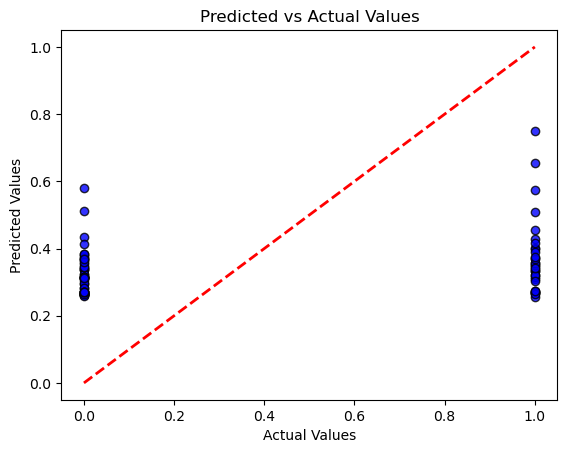

In [63]:
plt.scatter(y_test, y_pred, color='blue', alpha=0.8, edgecolors='black')

# Plot the diagonal line (Perfect predictions line)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Fit') #r-- is red dashed line

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual Values')
plt.show()